In [1]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [2]:
df = pd.read_csv(
    "../data/processed/vessel_arrival_delay_feature_engineered.csv"
)

In [3]:
feature_columns = [

    "Carrier",
    "Vessel_Type",
    "Origin_Port",
    "Destination_Port",

    "Distance_NM",
    "Scheduled_Transit_Days",
    "Departure_Delay_Hours",
    "Average_Speed_Knots",
    "Vessel_Age",
    "Cargo_Load_Percentage",
    "Port_Congestion_Index",
    "Weather_Severity",
    "Fuel_Price_USD",
    "Historical_Route_Delay",

    "Season",
    "Customs_Clearance_Risk",

    "Route",
    "Congestion_Level",
    "Weather_Category",
    "Vessel_Age_Group",
    "Load_Category",
    "Speed_Category",

    "Delay_Risk_Score"
]

X = df[feature_columns]

y = df["Late_Arrival"]

In [5]:
numeric_features = [

    "Distance_NM",
    "Scheduled_Transit_Days",
    "Departure_Delay_Hours",
    "Average_Speed_Knots",
    "Vessel_Age",
    "Cargo_Load_Percentage",
    "Port_Congestion_Index",
    "Weather_Severity",
    "Fuel_Price_USD",
    "Historical_Route_Delay",
    "Delay_Risk_Score"

]

categorical_features = [

    "Carrier",
    "Vessel_Type",
    "Origin_Port",
    "Destination_Port",

    "Season",
    "Customs_Clearance_Risk",

    "Route",
    "Congestion_Level",
    "Weather_Category",
    "Vessel_Age_Group",
    "Load_Category",
    "Speed_Category"

]

preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            StandardScaler(),
            numeric_features
        ),

        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )

    ]
)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,
    random_state=42,
    stratify=y
)

In [7]:
pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("classifier", RandomForestClassifier(random_state=42))

])

In [8]:
param_grid = {

    "classifier__n_estimators":

        [100, 200, 300, 500],

    "classifier__max_depth":

        [5, 10, 15, 20, None],

    "classifier__min_samples_split":

        [2, 5, 10],

    "classifier__min_samples_leaf":

        [1, 2, 4],

    "classifier__max_features":

        ["sqrt", "log2"]

}

In [9]:
cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)

In [10]:
random_search = RandomizedSearchCV(

    estimator=pipeline,

    param_distributions=param_grid,

    n_iter=20,

    scoring="roc_auc",

    cv=cv,

    verbose=2,

    random_state=42,

    n_jobs=-1

)

In [11]:
random_search.fit(

    X_train,

    y_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__max_depth': [5, 10, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum

In [12]:
print("Best Parameters:\n")

print(random_search.best_params_)

Best Parameters:

{'classifier__n_estimators': 300, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': None}


In [13]:
print(

    random_search.best_score_

)

0.9668840031995067


In [14]:
best_model = random_search.best_estimator_

In [15]:
predictions = best_model.predict(X_test)

probabilities = best_model.predict_proba(X_test)[:,1]

In [16]:
print("Accuracy :",

      accuracy_score(y_test,predictions))

print("Precision:",

      precision_score(y_test,predictions))

print("Recall:",

      recall_score(y_test,predictions))

print("F1 Score:",

      f1_score(y_test,predictions))

print("ROC AUC:",

      roc_auc_score(y_test,probabilities))

Accuracy : 0.9403532155948018
Precision: 0.9452347083926032
Recall: 0.9906820723071189
F1 Score: 0.967424931756142
ROC AUC: 0.9649587315428848


In [17]:
print(

classification_report(

    y_test,

    predictions

)
)

              precision    recall  f1-score   support

           0       0.87      0.52      0.65       318
           1       0.95      0.99      0.97      2683

    accuracy                           0.94      3001
   macro avg       0.91      0.75      0.81      3001
weighted avg       0.94      0.94      0.93      3001



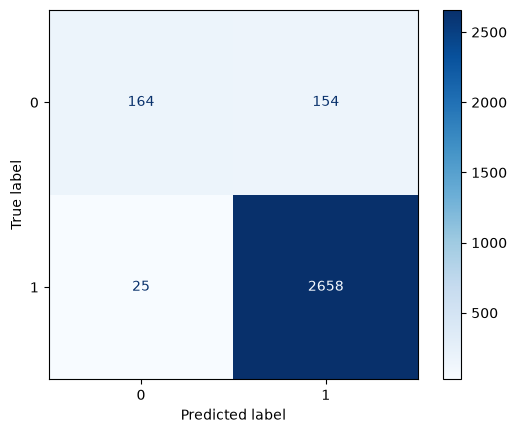

In [18]:
ConfusionMatrixDisplay.from_predictions(

    y_test,

    predictions,

    cmap="Blues"

)

plt.show()

In [19]:
scores = cross_val_score(

    best_model,

    X,

    y,

    cv=5,

    scoring="roc_auc"

)

print(scores)

print(scores.mean())

[0.95704728 0.96088704 0.96948188 0.97266191 0.96928862]
0.9658733465259208


In [20]:
joblib.dump(

    best_model,

    "../models/final_model.pkl"

)

print("Final Model Saved Successfully!")

Final Model Saved Successfully!


In [21]:
summary = pd.DataFrame({

    "Metric":[

        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC AUC"

    ],

    "Value":[

        accuracy_score(y_test,predictions),

        precision_score(y_test,predictions),

        recall_score(y_test,predictions),

        f1_score(y_test,predictions),

        roc_auc_score(y_test,probabilities)

    ]

})

summary

,Metric,Value
0,Accuracy,0.940353
1,Precision,0.945235
2,Recall,0.990682
3,F1,0.967425
4,ROC AUC,0.964959


In [22]:
summary.to_csv(
    "../reports/model_performance.csv",
    index=False
)